In [1]:
!pip -q install mediapipe opencv-python  # OpenCV (image processing library) and MediaPipe (body landmark detection library )

import cv2 # Reading images, Drawing lines, Drawing circles, Writing text
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

from mediapipe.tasks import python # Loads MediaPipe Task API.
from mediapipe.tasks.python import vision # Loads vision models. Used for pose detection.
import mediapipe as mp # Main MediaPipe package.

!wget -q -O pose_landmarker.task -c https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.5 MB/s eta 0:00:00


In [3]:
print("Upload a full-body image")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path) # Reads uploaded image


if image is None:
    raise Exception("Unable to read image")

Upload a full-body image


Saving download (1).jpg to download (1) (1).jpg


# Download Pose Landmarker model: Downloads pretrained Pose Landmarker model.
     # This model already knows: Human body structure, Joint locations, Pose estimation
     # No training required.

In [4]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w, _ = image.shape

In [5]:
# Create MediaPipe Image: Converts image into MediaPipe format. MediaPipe models require this format.

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb
)

base_options = python.BaseOptions(
    model_asset_path="pose_landmarker.task"
)

# Does not create body mask. Only detect landmarks.

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=False
)

In [6]:
detector = vision.PoseLandmarker.create_from_options(options)


# Detect Pose

result = detector.detect(mp_image) # Main prediction step. Model analyzes image. Returns body landmarks.


In [7]:
if len(result.pose_landmarks) == 0:
    print("No human body detected")

In [8]:
landmarks = result.pose_landmarks[0]
# ------------------------------------------------------
# Helper function
# ------------------------------------------------------
def get_point(index):
    lm = landmarks[index]
    return np.array([
        int(lm.x * w),
        int(lm.y * h)
    ])
# Landmark indices
LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_HIP = 23
RIGHT_HIP = 24
LEFT_ANKLE = 27
RIGHT_ANKLE = 28
NOSE = 0
# ------------------------------------------------------
# Extract coordinates
# ------------------------------------------------------
left_shoulder = get_point(LEFT_SHOULDER)
right_shoulder = get_point(RIGHT_SHOULDER)
left_hip = get_point(LEFT_HIP)
right_hip = get_point(RIGHT_HIP)
left_ankle = get_point(LEFT_ANKLE)
right_ankle = get_point(RIGHT_ANKLE)
nose = get_point(NOSE)

In [9]:
print("Left Shoulder:", left_shoulder)
print("Right Shoulder:", right_shoulder)
print("Left Hip:", left_hip)
print("Right Hip:", right_hip)
print("Left Ankle:", left_ankle)
print("Right Ankle:", right_ankle)
print("Nose:", nose)

Left Shoulder: [119  56]
Right Shoulder: [69 56]
Left Hip: [109 134]
Right Hip: [ 83 135]
Left Ankle: [121 248]
Right Ankle: [ 77 249]
Nose: [94 24]


In [10]:
# Measurements

shoulder_width = np.linalg.norm(
    left_shoulder - right_shoulder
)
hip_width = np.linalg.norm(
    left_hip - right_hip
)
ankle_mid = (
    left_ankle + right_ankle
) / 2
body_height = np.linalg.norm(
    nose - ankle_mid
)
shoulder_hip_ratio = shoulder_width / hip_width

# Simple classification

if shoulder_hip_ratio > 1.15:
    shape = "Athletic / Broad Shoulder"
elif shoulder_hip_ratio < 0.90:
    shape = "Pear Shape"
else:
    shape = "Balanced Shape"

In [11]:
print("Shoulder Width:", shoulder_width)
print("Hip Width:", hip_width)
print("Body Height:", body_height)
print("Shoulder/Hip Ratio:", shoulder_hip_ratio)

Shoulder Width: 50.0
Hip Width: 26.019223662515376
Body Height: 224.55567238437777
Shoulder/Hip Ratio: 1.9216561050602197


In [12]:
for lm in landmarks:
    x = int(lm.x * w)
    y = int(lm.y * h)
    cv2.circle(
        image,
        (x, y),
        4,
        (0, 255, 0),
        -1
    )

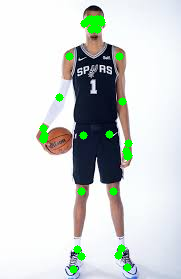

None


In [13]:
print(cv2_imshow(image))

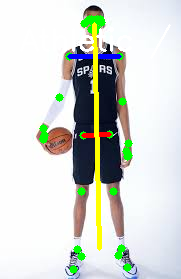

In [14]:

# ------------------------------------------------------
# Draw landmarks
# ------------------------------------------------------

# Shoulder line
cv2.line(
    image,
    tuple(left_shoulder),
    tuple(right_shoulder),
    (255, 0, 0),
    3
)
# Hip line
cv2.line(
    image,
    tuple(left_hip),
    tuple(right_hip),
    (0, 0, 255),
    3
)
# Height line
cv2.line(
    image,
    tuple(nose),
    tuple(ankle_mid.astype(int)),
    (0, 255, 255),
    3
)
cv2.putText(
    image,
    shape,
    (20, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 255, 255),
    2
)
cv2_imshow(image)

In [15]:
    print("\n========== BODY ANALYSIS ==========\n")

    print("Shoulder Width :", round(shoulder_width,2))
    print("Hip Width      :", round(hip_width,2))
    print("Body Height    :", round(body_height,2))
    print("Shoulder/Hip Ratio :", round(shoulder_hip_ratio,2))
    print("Predicted Shape :", shape)


========== BODY ANALYSIS ==========

Shoulder Width : 50.0
Hip Width      : 26.02
Body Height    : 224.56
Shoulder/Hip Ratio : 1.92
Predicted Shape : Athletic / Broad Shoulder
